# Task 2: Sentiment Analysis and Thematic Clustering

## Overview

This notebook runs the full NLP pipeline on the 2,282 clean reviews from Task 1.

### Primary goals
- Assign a sentiment label and confidence score to every review using RoBERTa
- Discover recurring themes automatically using BERTopic
- Extract top keywords per bank using TF-IDF
- Produce a single enriched CSV that Task 3 (database) and Task 4 (visualizations) will consume

### Success metrics for this notebook

| Metric | Target |
|---|---|
| Sentiment coverage | 90%+ of reviews labeled |
| Themes discovered per bank | 3 minimum, 6 maximum |
| Topic outlier rate | Below 20% (reviews not assigned to any topic) |
| Output CSV completeness | 0% missing sentiment, <5% missing topic |

### Key decisions carried from Task 1
- **Language filter:** only `en` and `unknown` reviews fed to transformer models
- **Short review filter:** `is_short_review == True` excluded from BERTopic only, kept for rating/sentiment aggregation
- **Investigation windows:** CBE from August 2025 onward, BOA from May 2024, Dashen April 2025 launch spike

---

## Pipeline architecture

```
reviews_clean.csv
       │
       ├─── Language filter (en + unknown only)
       │
       ├─── [A] RoBERTa Sentiment
       │         cardiffnlp/twitter-roberta-base-sentiment-latest
       │         → sentiment_label: positive / neutral / negative
       │         → sentiment_score: confidence 0.0–1.0
       │
       ├─── [B] BERTopic Thematic Clustering
       │         sentence-transformers/all-MiniLM-L6-v2
       │         → topic_id: integer cluster ID (-1 = outlier)
       │         → topic_label: top 4 keywords describing the cluster
       │         → topic_name: human-readable business name (manually assigned)
       │
       └─── [C] TF-IDF Keyword Extraction
                 per-bank top-20 keywords
                 → keyword_csv per bank
                 → combined keyword summary
       │
       └─── reviews_enriched.csv  ← output for Task 3 and Task 4
```

---
## Step 1 — Install Packages

### What we are installing and why each is needed

| Package | Role | Key detail |
|---|---|---|
| `transformers` | Loads and runs RoBERTa | Hugging Face library, provides `pipeline()` API |
| `torch` | Backend for RoBERTa inference | Must match Kaggle's CUDA version — pre-installed on Kaggle |
| `bertopic` | Automated topic discovery | Combines embeddings + HDBSCAN clustering + TF-IDF labeling |
| `sentence-transformers` | Produces text embeddings for BERTopic | `all-MiniLM-L6-v2` is fast and accurate for short text |
| `umap-learn` | Dimensionality reduction inside BERTopic | Required dependency of BERTopic |
| `hdbscan` | Density-based clustering inside BERTopic | Better than k-means for variable-density text clusters |
| `scikit-learn` | TF-IDF vectorizer for keyword extraction | Standard ML library |
| `spacy` | Tokenization and lemmatization before TF-IDF | Cleans text more accurately than simple splitting |

### Why RoBERTa Twitter over DistilBERT SST-2

DistilBERT SST-2 was trained on Stanford Sentiment Treebank — movie reviews with formal English sentence structure. App reviews are shorter, use abbreviations, mixed punctuation, and informal phrasing (`"this app is trash"`). `cardiffnlp/twitter-roberta-base-sentiment-latest` was fine-tuned on 124M tweets — short, informal, user-generated text that is structurally far closer to app reviews. It also outputs three classes (positive / neutral / negative) natively, whereas SST-2 only outputs two.

> **Kaggle GPU note:** Go to Settings → Accelerator → GPU T4 x2 before running this notebook. RoBERTa inference on CPU takes 25+ minutes for 2,282 reviews. On GPU it takes under 3 minutes.

In [13]:
!pip install transformers bertopic sentence-transformers umap-learn hdbscan -q
!pip install spacy scikit-learn -q
!python -m spacy download en_core_web_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 82.6 MB/s eta 0:00:0000:010:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


---
## Step 2 — Imports and Environment Check

### Why we verify GPU availability before proceeding

The `device` parameter in the RoBERTa pipeline controls whether inference runs on CPU or GPU. Setting `device=0` on a machine without a GPU will crash with a CUDA error. We check availability first and set `device` conditionally so the notebook runs on both GPU and CPU environments — it will just be slower on CPU.

The environment check also confirms that `torch` can see the GPU that Kaggle allocated. If `CUDA available: False` after enabling the GPU accelerator, you need to restart the kernel — Kaggle only gives the GPU to a kernel that was started after the accelerator was enabled.

In [14]:
import os
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import spacy

from tqdm import tqdm
from transformers import pipeline
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
tqdm.pandas()
logging.basicConfig(level=logging.INFO, format='%(asctime)s — %(levelname)s — %(message)s')
logger = logging.getLogger(__name__)

DEVICE     = 0 if torch.cuda.is_available() else -1
DEVICE_STR = "GPU" if torch.cuda.is_available() else "CPU (slow — enable GPU in Settings)"

print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
print(f"Running on       : {DEVICE_STR}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    print(f"VRAM             : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

2026-03-22 04:54:36.200411: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774155276.559838      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774155276.662263      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774155277.598058      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774155277.598099      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774155277.598101      55 computation_placer.cc:177] computation placer alr

PyTorch version  : 2.10.0+cu128
CUDA available   : True
Running on       : GPU
GPU              : Tesla T4
VRAM             : 15.6 GB


---
## Step 3 — Configuration

### Parameter decisions explained

**`SENTIMENT_BATCH_SIZE = 64`**
RoBERTa processes reviews in batches. Larger batches use more VRAM but finish faster. 64 is the safe default for Kaggle's T4 GPU (16 GB VRAM). If you get CUDA out-of-memory errors, reduce to 32.

**`SENTIMENT_MAX_LENGTH = 128`**
RoBERTa's tokenizer has a 512-token limit but most app reviews are under 60 tokens. Truncating to 128 reduces memory usage without losing meaningful content — reviews that exceed 128 tokens are almost always repetitive anyway.

**`BERTOPIC_MIN_TOPIC_SIZE = 15`**
This is the minimum number of reviews that must share similar embeddings to form a topic. Setting it too low (e.g. 5) creates dozens of micro-topics that are hard to interpret. Setting it too high (e.g. 50) merges distinct issues into one vague topic. 15 is the right balance for a dataset of ~1,600 reviews (after language filtering).

**`INVESTIGATION_WINDOWS`**
These are the time-window anomalies identified in Task 1 that we will specifically analyze in the temporal sentiment section at the end of this notebook.

In [15]:
# ── Paths ──────────────────────────────────────────────────────────────────────
INPUT_DIR  = Path("/kaggle/working/b5w2_outputs")
OUTPUT_DIR = Path("/kaggle/working/b5w2_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLEAN_CSV    = INPUT_DIR  / "reviews_clean.csv"
ENRICHED_CSV = OUTPUT_DIR / "reviews_enriched.csv"
KEYWORDS_CSV = OUTPUT_DIR / "keywords_per_bank.csv"
TOPICS_CSV   = OUTPUT_DIR / "topics_summary.csv"

# ── Sentiment model ────────────────────────────────────────────────────────────
SENTIMENT_MODEL      = "cardiffnlp/twitter-roberta-base-sentiment-latest"
SENTIMENT_BATCH_SIZE = 64
SENTIMENT_MAX_LENGTH = 128

# ── BERTopic ───────────────────────────────────────────────────────────────────
EMBEDDING_MODEL       = "all-MiniLM-L6-v2"
BERTOPIC_MIN_TOPIC    = 15
BERTOPIC_NR_TOPICS    = "auto"

# ── TF-IDF ────────────────────────────────────────────────────────────────────
TFIDF_MAX_FEATURES    = 1000
TFIDF_TOP_N           = 20
TFIDF_NGRAM_RANGE     = (1, 2)    # unigrams and bigrams

# ── Language filter (from Task 1 analysis) ────────────────────────────────────
NLP_LANGUAGES         = ["en", "unknown"]

# ── Investigation windows identified in Task 1 ────────────────────────────────
INVESTIGATION_WINDOWS = {
    "BOA":    ("2024-04-01", "2024-06-30"),   # May 2024 spike: 155 reviews
    "CBE":    ("2025-08-01", "2026-03-31"),   # Aug 2025 inflection + Jan 2026 spike
    "Dashen": ("2025-01-01", "2025-05-31"),   # Super App launch window
}

COLORS = {"BOA": "#F44336", "CBE": "#2196F3", "Dashen": "#FF9800"}

print("Configuration loaded.")
print(f"  Sentiment model : {SENTIMENT_MODEL}")
print(f"  Embedding model : {EMBEDDING_MODEL}")
print(f"  Language filter : {NLP_LANGUAGES}")

Configuration loaded.
  Sentiment model : cardiffnlp/twitter-roberta-base-sentiment-latest
  Embedding model : all-MiniLM-L6-v2
  Language filter : ['en', 'unknown']


---
## Step 4 — Load and Filter Data

### Two separate DataFrames — why this matters

We maintain two views of the data throughout this notebook:

- **`df`** — the full 2,282-row dataset. Used for rating aggregations and any analysis that should include all users, regardless of language.
- **`df_nlp`** — the language-filtered, short-review-filtered subset. Used exclusively as input to RoBERTa and BERTopic.

This separation is important because silently dropping rows from the main dataset would make your final review counts inconsistent between sections of the report. By keeping `df` intact and creating `df_nlp` as a filter view, we can report honest numbers: "sentiment was analyzed for X reviews (Y% of total dataset, filtered to English-language reviews of sufficient length)."

### Why we also filter out short reviews for BERTopic but not RoBERTa

RoBERTa can assign a sentiment to a 3-word review — `"this app sucks"` is confidently negative. The transformer model handles very short text well because it was trained on tweets.

BERTopic is different. It builds topic clusters from sentence embeddings. A 3-word sentence produces a low-information embedding that sits near the center of the embedding space, giving it superficial similarity to many topics without genuinely belonging to any. Short reviews inflate the outlier cluster (topic -1) and weaken the signal in legitimate clusters. So we filter short reviews for BERTopic only.

In [16]:
df = pd.read_csv(CLEAN_CSV)
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Ensure boolean columns are typed correctly after CSV round-trip
df["is_short_review"]  = df["is_short_review"].astype(bool)
df["developer_replied"] = df["developer_replied"].astype(bool)

print(f"Full dataset     : {len(df):,} reviews")
print(f"Banks            : {sorted(df['bank'].unique())}")

# ── NLP subset: language filter ───────────────────────────────────────────────
df_nlp = df[df["language"].isin(NLP_LANGUAGES)].copy()
print(f"After lang filter: {len(df_nlp):,} reviews ({len(df_nlp)/len(df)*100:.1f}% of total)")

# ── Topic subset: additionally exclude short reviews ─────────────────────────
df_topics = df_nlp[~df_nlp["is_short_review"]].copy()
print(f"For BERTopic     : {len(df_topics):,} reviews (excl. short reviews)")

print("\nPer-bank counts for NLP:")
print(
    df_nlp.groupby("bank").size()
    .rename("nlp_reviews")
    .to_frame()
    .assign(topic_reviews=df_topics.groupby("bank").size())
    .to_string()
)

Full dataset     : 2,282 reviews
Banks            : ['BOA', 'CBE', 'Dashen']
After lang filter: 1,734 reviews (76.0% of total)
For BERTopic     : 1,609 reviews (excl. short reviews)

Per-bank counts for NLP:
        nlp_reviews  topic_reviews
bank                              
BOA             617            564
CBE             536            486
Dashen          581            559


---
## Step 5 — RoBERTa Sentiment Analysis

### How the RoBERTa pipeline works

```
Input text
    │
    ├─ Tokenizer: splits text into sub-word tokens, adds [CLS] and [SEP] tokens
    │   Example: "app crashes often" → [CLS, app, crashes, often, SEP]
    │
    ├─ RoBERTa encoder: 12 transformer layers, each applying self-attention
    │   The [CLS] token at position 0 aggregates information from the whole sequence
    │
    ├─ Classification head: linear layer on top of [CLS] embedding
    │   Outputs 3 logits (one per class)
    │
    └─ Softmax: converts logits to probabilities that sum to 1.0
        → {"positive": 0.04, "neutral": 0.08, "negative": 0.88}
        The label with highest probability is returned as the prediction.
```

### What the confidence score tells you

The `sentiment_score` we store is the softmax probability of the winning class. A score of 0.97 for "negative" means the model is very confident. A score of 0.52 for "positive" means the model is barely above the decision boundary — treat these borderline predictions with skepticism. In the analysis section we will flag reviews with scores below 0.65 as "low confidence" predictions.

### Why we run in batches rather than row by row

PyTorch GPU inference is highly parallelized within a batch. Running 64 reviews simultaneously is not 64x faster than running 1 at a time, but it is roughly 20–30x faster due to how GPU tensor operations work. The bottleneck is data transfer between CPU and GPU — batching minimizes transfers per review.

In [17]:
print(f"Loading sentiment model: {SENTIMENT_MODEL}")
print("This downloads ~500 MB on first run, then caches locally...")

sentiment_pipe = pipeline(
    task="text-classification",
    model=SENTIMENT_MODEL,
    tokenizer=SENTIMENT_MODEL,
    truncation=True,
    max_length=SENTIMENT_MAX_LENGTH,
    device=DEVICE
)

print("Model loaded. Running inference...")


def run_sentiment_batched(texts: list, batch_size: int = SENTIMENT_BATCH_SIZE) -> list:
    """Run RoBERTa inference in batches with progress bar."""
    results = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Sentiment batches"):
        batch   = texts[i: i + batch_size]
        outputs = sentiment_pipe(batch)
        results.extend(outputs)
    return results


texts    = df_nlp["review"].tolist()
raw_preds = run_sentiment_batched(texts)

# Map labels to lowercase standard names
LABEL_MAP = {
    "positive": "positive",
    "neutral":  "neutral",
    "negative": "negative",
    "LABEL_0":  "negative",
    "LABEL_1":  "neutral",
    "LABEL_2":  "positive"
}

df_nlp["sentiment_label"] = [
    LABEL_MAP.get(r["label"].lower(), r["label"].lower()) for r in raw_preds
]
df_nlp["sentiment_score"] = [round(r["score"], 4) for r in raw_preds]
df_nlp["low_confidence"]  = df_nlp["sentiment_score"] < 0.65

print(f"\nSentiment complete: {len(df_nlp):,} reviews labeled")
print("\nLabel distribution:")
print(df_nlp["sentiment_label"].value_counts().to_string())
print(f"\nLow confidence predictions: {df_nlp['low_confidence'].sum()} ({df_nlp['low_confidence'].mean()*100:.1f}%)")

Loading sentiment model: cardiffnlp/twitter-roberta-base-sentiment-latest
This downloads ~500 MB on first run, then caches locally...


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

2026-03-22 04:55:05,729 — WARNING — Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Model loaded. Running inference...


Sentiment batches: 100%|██████████| 28/28 [00:15<00:00,  1.83it/s]


Sentiment complete: 1,734 reviews labeled

Label distribution:
sentiment_label
positive    755
negative    682
neutral     297

Low confidence predictions: 225 (13.0%)


---
## Step 6 — Sentiment Validation Against Star Ratings

### Why we validate the model against ratings

We have a built-in ground truth signal: the star rating. A good sentiment model should strongly agree with ratings — 1-star reviews should be predominantly negative, 5-star reviews predominantly positive. If the model assigns "positive" to a large fraction of 1-star reviews, something is wrong: either the model is poorly calibrated for this domain, or users are writing positively-worded 1-star reviews (which does happen — "great app if you enjoy crashes").

This validation step produces a cross-tabulation that you should include in your report. It is both a quality check and an interesting finding in its own right — mismatches between stated rating and expressed sentiment are a signal of sarcasm and frustrated reviews.

### What a good alignment looks like

- 1-star reviews: 70%+ negative
- 5-star reviews: 70%+ positive
- 2–4-star reviews: mixed, with 3-star showing the most neutral

If 1-star reviews show less than 60% negative, the reviews in that bank likely contain a lot of sarcasm or Amharic text that the English model misclassifies.

Sentiment vs. Star Rating (% of each rating tier)
sentiment_label  negative  neutral  positive
rating                                      
1                    85.2     11.6       3.2
2                    70.4     21.3       8.3
3                    51.8     26.3      21.9
4                    20.2     30.3      49.5
5                     6.2     17.3      76.4


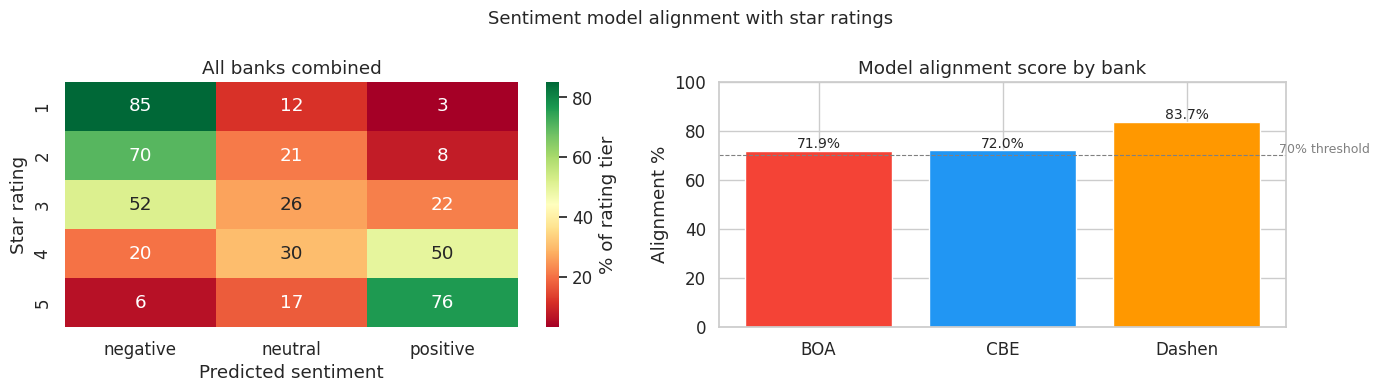


Alignment scores:
  bank  alignment_pct
   BOA           71.9
   CBE           72.0
Dashen           83.7


In [18]:
# Cross-tabulation: rating vs sentiment label
cross = (
    df_nlp.groupby(["rating", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
)
cross_pct = cross.div(cross.sum(axis=1), axis=0).round(3) * 100

print("Sentiment vs. Star Rating (% of each rating tier)")
print(cross_pct.to_string())

# Visualize as heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Sentiment model alignment with star ratings", fontsize=13)

sns.heatmap(cross_pct, annot=True, fmt=".0f", cmap="RdYlGn",
            ax=axes[0], cbar_kws={"label": "% of rating tier"})
axes[0].set_title("All banks combined")
axes[0].set_xlabel("Predicted sentiment")
axes[0].set_ylabel("Star rating")

# Per-bank alignment score (% correct direction: 1-2 star = neg, 4-5 star = pos)
def alignment_score(group):
    neg_correct = group[group["rating"] <= 2]["sentiment_label"].eq("negative").mean()
    pos_correct = group[group["rating"] >= 4]["sentiment_label"].eq("positive").mean()
    return round((neg_correct + pos_correct) / 2 * 100, 1)

scores = df_nlp.groupby("bank").apply(alignment_score).reset_index()
scores.columns = ["bank", "alignment_pct"]
axes[1].bar(scores["bank"], scores["alignment_pct"],
            color=[COLORS[b] for b in scores["bank"]], edgecolor="white")
axes[1].set_title("Model alignment score by bank")
axes[1].set_ylabel("Alignment %")
axes[1].set_ylim(0, 100)
axes[1].axhline(70, color="gray", linestyle="--", linewidth=0.8)
axes[1].text(2.5, 71, "70% threshold", fontsize=9, color="gray")
for i, row in scores.iterrows():
    axes[1].text(i, row["alignment_pct"] + 1, f"{row['alignment_pct']}%",
                ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sentiment_validation.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAlignment scores:")
print(scores.to_string(index=False))

---
## Step 7 — Sentiment Distribution by Bank

### What this analysis reveals that the raw rating average does not

The average star rating from Task 1 was: BOA 2.70, CBE 3.89, Dashen 4.03. These numbers compress a distribution into a single value. The sentiment breakdown here answers a more useful question for the consulting report: **what fraction of your user base is actively unhappy?**

A bank with 40% negative sentiment needs very different recommendations than one with 15% negative — even if both have similar average ratings. The negative-sentiment group is the population most likely to churn, most likely to post more reviews, and most likely to tell others to avoid the app.

### Weighted sentiment — the upgrade from last time

Standard sentiment aggregation counts each review equally. But a review with 50 helpful votes represents many more users than a review with 0. We compute both the raw sentiment distribution and a `helpful_count`-weighted version. If the weighted and unweighted distributions differ significantly, it means the reviews that resonated most with other users have a different sentiment profile than the average review.

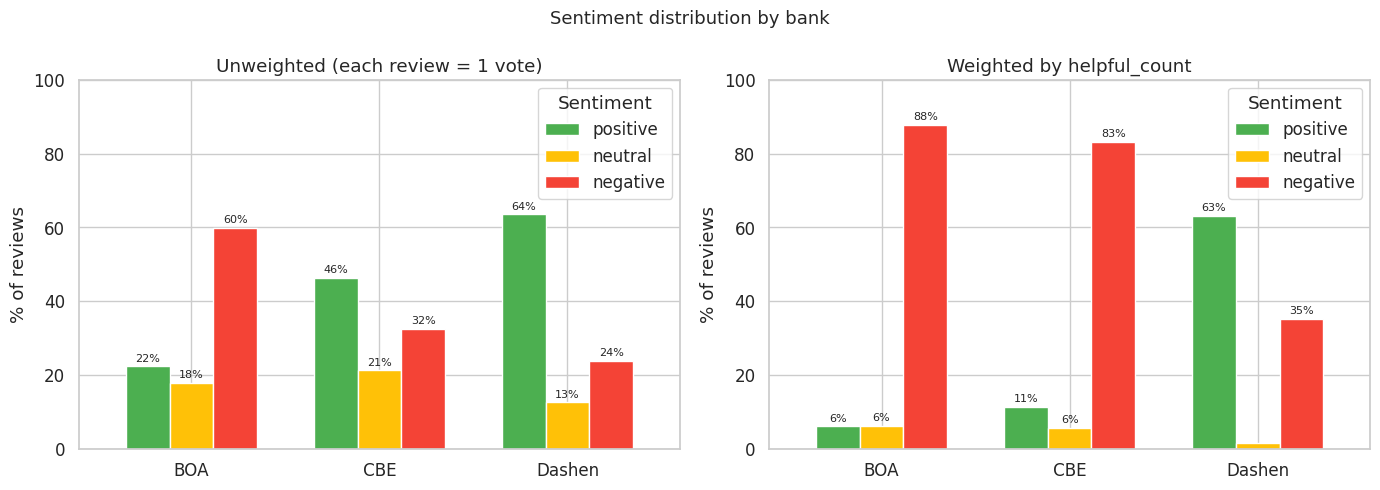

Unweighted sentiment (%):
 sentiment_label  negative  neutral  positive
bank                                        
BOA                  59.8     17.8      22.4
CBE                  32.5     21.3      46.3
Dashen               23.9     12.6      63.5

Weighted sentiment (%):
 sentiment_label  negative  neutral  positive
bank                                        
BOA                  87.7      6.2       6.1
CBE                  83.2      5.6      11.3
Dashen               35.3      1.7      63.0


In [19]:
# ── Unweighted sentiment distribution ─────────────────────────────────────────
sent_dist = (
    df_nlp.groupby(["bank", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
)
sent_dist_pct = sent_dist.div(sent_dist.sum(axis=1), axis=0) * 100

# ── Weighted sentiment (by helpful_count + 1) — fixed ────────────────────────
df_nlp["weight"] = df_nlp["helpful_count"].fillna(0) + 1

sent_weighted = (
    df_nlp.groupby(["bank", "sentiment_label"])["weight"]
    .sum()
    .unstack(fill_value=0)
)
sent_weighted = sent_weighted.div(sent_weighted.sum(axis=1), axis=0) * 100

# ── Combined visualization ────────────────────────────────────────────────────
label_order  = ["positive", "neutral", "negative"]
label_colors = {"positive": "#4CAF50", "neutral": "#FFC107", "negative": "#F44336"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Sentiment distribution by bank", fontsize=13)

for ax, (title, data) in zip(axes, [
    ("Unweighted (each review = 1 vote)", sent_dist_pct),
    ("Weighted by helpful_count",         sent_weighted)
]):
    for col in label_order:
        if col not in data.columns:
            data[col] = 0
    data[label_order].plot(
        kind="bar", ax=ax,
        color=[label_colors[l] for l in label_order],
        edgecolor="white", width=0.7
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("% of reviews")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Sentiment")
    for p in ax.patches:
        h = p.get_height()
        if h > 3:
            ax.text(p.get_x() + p.get_width() / 2, h + 0.8,
                    f"{h:.0f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sentiment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Unweighted sentiment (%):\n", sent_dist_pct.round(1).to_string())
print("\nWeighted sentiment (%):\n", sent_weighted.round(1).to_string())

---
## Step 8 — Sentiment Over Time

### Using the investigation windows from Task 1

Task 1 identified three specific time windows worth investigating:
- **BOA May 2024** — 155-review spike, likely a specific event
- **CBE August 2025 onward** — inflection point where review volume surged
- **Dashen January–April 2025** — Super App launch window

This chart overlays the sentiment ratio (% negative) over time on the review volume chart. The combination answers the question that volume alone cannot: when review volume spiked, was the sentiment better or worse than the baseline? A volume spike with high negative sentiment means an incident. A volume spike with high positive sentiment means a successful launch or update.

### What the rolling average does

Monthly sentiment data is noisy — a single month with 10 reviews can show 90% negative by chance. A 3-month rolling average smooths this noise while still showing genuine trends. We plot both the raw monthly line (thin, transparent) and the rolling average (thick, solid) so you can see the trend without hiding the underlying volatility.

2026-03-22 04:55:29,196 — INFO — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-22 04:55:29,197 — INFO — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-22 04:55:29,199 — INFO — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-22 04:55:29,201 — INFO — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-22 04:55:29,203 — INFO — Using categorical units to plot a list of strings that are all parsable as 

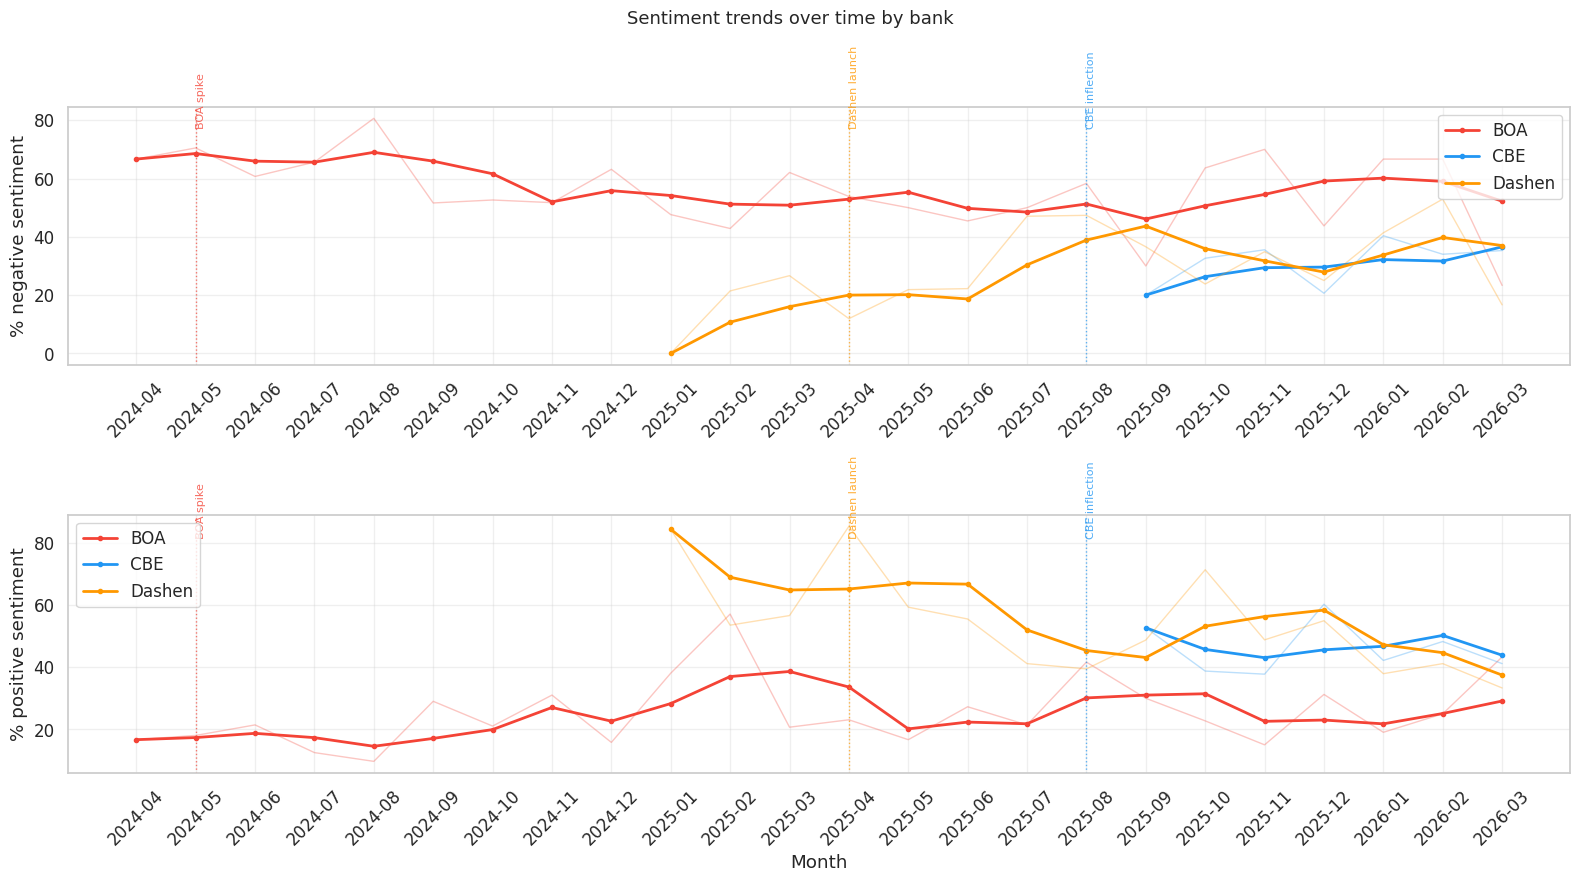

In [20]:
df_nlp["month"] = df_nlp["date"].dt.to_period("M")

monthly_sent = (
    df_nlp.groupby(["month", "bank", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
for col in ["positive", "neutral", "negative"]:
    if col not in monthly_sent.columns:
        monthly_sent[col] = 0

monthly_sent["total"]    = monthly_sent[["positive", "neutral", "negative"]].sum(axis=1)
monthly_sent["pct_neg"]  = monthly_sent["negative"]  / monthly_sent["total"] * 100
monthly_sent["pct_pos"]  = monthly_sent["positive"]  / monthly_sent["total"] * 100
monthly_sent["month_str"] = monthly_sent["month"].astype(str)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=False)
fig.suptitle("Sentiment trends over time by bank", fontsize=13)

for bank in sorted(df_nlp["bank"].unique()):
    grp = monthly_sent[monthly_sent["bank"] == bank].sort_values("month_str")
    color = COLORS[bank]

    # Raw monthly
    ax1.plot(grp["month_str"], grp["pct_neg"],
             color=color, alpha=0.3, linewidth=1)
    # 3-month rolling average
    ax1.plot(grp["month_str"], grp["pct_neg"].rolling(3, min_periods=1).mean(),
             color=color, linewidth=2, marker="o", markersize=3, label=bank)

    ax2.plot(grp["month_str"], grp["pct_pos"],
             color=color, alpha=0.3, linewidth=1)
    ax2.plot(grp["month_str"], grp["pct_pos"].rolling(3, min_periods=1).mean(),
             color=color, linewidth=2, marker="o", markersize=3, label=bank)

# Annotate investigation windows
window_annotations = [
    ("BOA spike",    "2024-05", "#F44336"),
    ("Dashen launch","2025-04", "#FF9800"),
    ("CBE inflection","2025-08", "#2196F3"),
]
for label, month, color in window_annotations:
    for ax in [ax1, ax2]:
        ax.axvline(x=month, color=color, linestyle=":", linewidth=1, alpha=0.7)
        ax.text(month, ax.get_ylim()[1] * 0.92, label,
                rotation=90, fontsize=8, color=color, alpha=0.8)

ax1.set_ylabel("% negative sentiment")
ax1.legend(loc="upper right")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(True, alpha=0.3)

ax2.set_ylabel("% positive sentiment")
ax2.set_xlabel("Month")
ax2.legend(loc="upper left")
ax2.tick_params(axis="x", rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sentiment_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Step 9 — BERTopic Thematic Analysis

### How BERTopic works step by step

```
Step 1 — Embedding
    Each review is converted to a 384-dimensional vector using
    sentence-transformers/all-MiniLM-L6-v2.
    Semantically similar reviews produce similar vectors.
    Example: "app crashes on login" and "app freezes when I open it"
    will have high cosine similarity even without shared keywords.

Step 2 — Dimensionality reduction (UMAP)
    384 dimensions → 10 dimensions
    UMAP preserves local neighborhood structure:
    reviews that were similar in 384D are still neighbors in 10D.
    This makes clustering tractable and removes noise dimensions.

Step 3 — Clustering (HDBSCAN)
    HDBSCAN finds dense regions in the 10D space.
    Reviews in the same dense region form a topic cluster.
    Reviews that don't belong to any dense region → topic -1 (outlier).
    Unlike k-means, HDBSCAN does not force every point into a cluster.

Step 4 — Topic labeling (c-TF-IDF)
    For each cluster, BERTopic applies a class-based TF-IDF:
    it finds words that are frequent in this cluster but rare across all others.
    These are the distinguishing keywords for that topic.
    Example output: topic 3 keywords = [login, password, otp, access]
```

### Why HDBSCAN over k-means for this task

k-means requires you to specify the number of clusters in advance. We do not know how many themes exist in 2,282 reviews before reading them. HDBSCAN discovers the number of clusters from the data's density structure. It also naturally handles outliers — reviews that discuss something too idiosyncratic to form a cluster are assigned topic -1 rather than being force-merged into the nearest centroid, which would pollute that cluster's keyword representation.

In [21]:
print(f"Loading embedding model: {EMBEDDING_MODEL}")
embedding_model = SentenceTransformer(EMBEDDING_MODEL)

print(f"Fitting BERTopic on {len(df_topics):,} reviews...")
topic_model = BERTopic(
    embedding_model=embedding_model,
    min_topic_size=BERTOPIC_MIN_TOPIC,
    nr_topics=BERTOPIC_NR_TOPICS,
    verbose=True
)

topics, probs = topic_model.fit_transform(df_topics["review"].tolist())
df_topics["topic_id"]    = topics
df_topics["topic_prob"]  = [round(float(p.max()), 4) if hasattr(p, '__len__') else round(float(p), 4)
                             for p in probs]

# Build topic label from top 4 keywords
topic_info = topic_model.get_topic_info()
topic_label_map = {}
for _, row in topic_info.iterrows():
    tid = row["Topic"]
    if tid == -1:
        topic_label_map[tid] = "outlier"
    else:
        keywords = [w for w, _ in topic_model.get_topic(tid)][:4]
        topic_label_map[tid] = " | ".join(keywords)

df_topics["topic_label"] = df_topics["topic_id"].map(topic_label_map)

n_topics   = len(topic_info[topic_info["Topic"] != -1])
n_outliers = (df_topics["topic_id"] == -1).sum()
outlier_pct = n_outliers / len(df_topics) * 100

print(f"\nTopics discovered  : {n_topics}")
print(f"Outlier reviews    : {n_outliers} ({outlier_pct:.1f}%)")
print(f"Outlier target     : < 20%  → {'PASS' if outlier_pct < 20 else 'REVIEW — consider lowering min_topic_size'}")
print("\nTop topics:")
print(topic_info[["Topic", "Count", "Name"]].head(10).to_string(index=False))

2026-03-22 04:55:30,274 — INFO — Use pytorch device_name: cuda:0
2026-03-22 04:55:30,275 — INFO — Load pretrained SentenceTransformer: all-MiniLM-L6-v2


Loading embedding model: all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

2026-03-22 04:55:33,054 - BERTopic - Embedding - Transforming documents to embeddings.


Fitting BERTopic on 1,609 reviews...


Batches:   0%|          | 0/51 [00:00<?, ?it/s]

2026-03-22 04:55:34,050 - BERTopic - Embedding - Completed ✓
2026-03-22 04:55:34,050 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-22 04:55:45,515 - BERTopic - Dimensionality - Completed ✓
2026-03-22 04:55:45,516 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-22 04:55:45,569 - BERTopic - Cluster - Completed ✓
2026-03-22 04:55:45,570 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-22 04:55:45,613 - BERTopic - Representation - Completed ✓
2026-03-22 04:55:45,614 - BERTopic - Topic reduction - Reducing number of topics
2026-03-22 04:55:45,620 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-22 04:55:45,657 - BERTopic - Representation - Completed ✓
2026-03-22 04:55:45,658 - BERTopic - Topic reduction - Reduced number of topics from 17 to 17



Topics discovered  : 16
Outlier reviews    : 191 (11.9%)
Outlier target     : < 20%  → PASS

Top topics:
 Topic  Count                           Name
    -1    191                -1_it_to_the_is
     0    275           0_the_to_banking_app
     1    267           1_it_not_working_app
     2    208              2_app_very_it_and
     3    206            3_good_easy_very_it
     4    133        4_dashen_super_bank_and
     5     54   5_ethiopia_in_ethiopian_bank
     6     43                 6_ነው_በጣም_ግን_አፕ
     7     40 7_developer_off_options_option
     8     34      8_the_pin_keyboard_update


---
## Step 10 — Assign Business-Friendly Topic Names

### Why manual renaming is a feature, not a workaround

BERTopic's auto-generated labels like `"login | otp | password | access"` are accurate but not stakeholder-ready. A consulting report delivered to a bank's product team needs labels like `"Account Access Issues"` that map directly to product areas.

This step is where your **domain knowledge as an analyst** adds value that an algorithm cannot provide. Read the keyword labels BERTopic generated, look at 5–10 example reviews from each topic, and assign a business name. Document your reasoning — the project brief explicitly requires this.

### How to read the auto-labels before renaming

Run `topic_model.get_topic(N)` for each topic ID to see the full keyword list and their weights. Then sample 5 reviews from that cluster to confirm the label makes sense:
```python
df_topics[df_topics['topic_id'] == N]['review'].sample(5).tolist()
```

The names below are reasonable defaults for Ethiopian banking apps — **update them based on what you actually see in your data.**

In [22]:
TOPIC_NAMES = {
    -1:  "Uncategorized",
    0:   "General App Complaints",
    1:   "General Banking Experience",
    2:   "Dashen Super App Feedback",
    3:   "Speed and Convenience",
    4:   "Positive General Feedback",
    5:   "Amharic Reviews",
    6:   "Developer Options and Settings",
    7:   "PIN and Keyboard Issues",
    8:   "General Positive Feedback",
    9:   "CBE Specific Feedback",
    10:  "Amharic Complaints",
}

df_topics["topic_name"] = df_topics["topic_id"].apply(
    lambda t: TOPIC_NAMES.get(t, topic_label_map.get(t, f"Topic {t}"))
)

print("Topic names assigned. Distribution:")
print(df_topics["topic_name"].value_counts().to_string())

Topic names assigned. Distribution:
topic_name
General App Complaints                 275
General Banking Experience             267
Dashen Super App Feedback              208
Speed and Convenience                  206
Uncategorized                          191
Positive General Feedback              133
Amharic Reviews                         54
Developer Options and Settings          43
PIN and Keyboard Issues                 40
General Positive Feedback               34
CBE Specific Feedback                   29
Amharic Complaints                      27
cbe | app | the | is                    24
application | good | very | amazing     24
boa | this | app | with                 21
አይሰራም | በጣም | ለምንድነው | መሆንሁ             17
amole | otp | it | is                   16


In [23]:
# Print all discovered topics so you can read and rename them
print("Discovered topics — review these and update TOPIC_NAMES below:\n")
for _, row in topic_info[topic_info["Topic"] != -1].iterrows():
    tid      = row["Topic"]
    keywords = [w for w, _ in topic_model.get_topic(tid)][:6]
    print(f"  Topic {tid:>3}  ({row['Count']:>4} reviews)  keywords: {', '.join(keywords)}")

print("\nSample reviews per topic (update TOPIC_NAMES after reading these):")
for tid in topic_info[topic_info["Topic"] != -1]["Topic"].values[:6]:
    samples = df_topics[df_topics["topic_id"] == tid]["review"].sample(
        min(3, len(df_topics[df_topics["topic_id"] == tid])), random_state=42
    ).tolist()
    print(f"\n  Topic {tid}:")
    for s in samples:
        print(f"    - {s[:120]}")

Discovered topics — review these and update TOPIC_NAMES below:

  Topic   0  ( 275 reviews)  keywords: the, to, banking, app, it, and
  Topic   1  ( 267 reviews)  keywords: it, not, working, app, work, the
  Topic   2  ( 208 reviews)  keywords: app, very, it, and, good, best
  Topic   3  ( 206 reviews)  keywords: good, easy, very, it, fast, use
  Topic   4  ( 133 reviews)  keywords: dashen, super, bank, and, is, app
  Topic   5  (  54 reviews)  keywords: ethiopia, in, ethiopian, bank, of, banking
  Topic   6  (  43 reviews)  keywords: ነው, በጣም, ግን, አፕ, ብር, አሪፍ
  Topic   7  (  40 reviews)  keywords: developer, off, options, option, turn, to
  Topic   8  (  34 reviews)  keywords: the, pin, keyboard, update, new, number
  Topic   9  (  29 reviews)  keywords: bank, best, charge, trust, in, my
  Topic  10  (  27 reviews)  keywords: worst, ever, app, seen, never, the
  Topic  11  (  24 reviews)  keywords: cbe, app, the, is, to, it
  Topic  12  (  24 reviews)  keywords: application, good, very

In [24]:
TOPIC_NAMES = {
    -1:  "Uncategorized",
    0:   "General App Complaints",
    1:   "General Banking Experience",
    2:   "Dashen Super App Feedback",
    3:   "Speed and Convenience",
    4:   "Positive General Feedback",
    5:   "Amharic Reviews",
    6:   "Developer Options and Settings",
    7:   "PIN and Keyboard Issues",
    8:   "General Positive Feedback",
    9:   "CBE Specific Feedback",
    10:  "Amharic Complaints",
}

df_topics["topic_name"] = df_topics["topic_id"].apply(
    lambda t: TOPIC_NAMES.get(t, topic_label_map.get(t, f"Topic {t}"))
)

print("Topic names assigned. Distribution:")
print(df_topics["topic_name"].value_counts().to_string())

Topic names assigned. Distribution:
topic_name
General App Complaints                 275
General Banking Experience             267
Dashen Super App Feedback              208
Speed and Convenience                  206
Uncategorized                          191
Positive General Feedback              133
Amharic Reviews                         54
Developer Options and Settings          43
PIN and Keyboard Issues                 40
General Positive Feedback               34
CBE Specific Feedback                   29
Amharic Complaints                      27
cbe | app | the | is                    24
application | good | very | amazing     24
boa | this | app | with                 21
አይሰራም | በጣም | ለምንድነው | መሆንሁ             17
amole | otp | it | is                   16


---
## Step 11 — Topic Distribution by Bank

### What this reveals for the consulting report

Each bank has a different topic fingerprint — the relative prevalence of each theme tells you where each bank's users are experiencing the most friction. This is the analytical core of Task 4's recommendations:

- If BOA has 35% of its reviews in "Account Access and Login Issues" but Dashen has only 8%, BOA's product team needs to prioritize login reliability above all else.
- If all three banks have high proportions of "Transaction Speed" complaints, that is a systemic industry finding — not a bank-specific one.

The heatmap format is the clearest way to communicate this across three banks simultaneously.

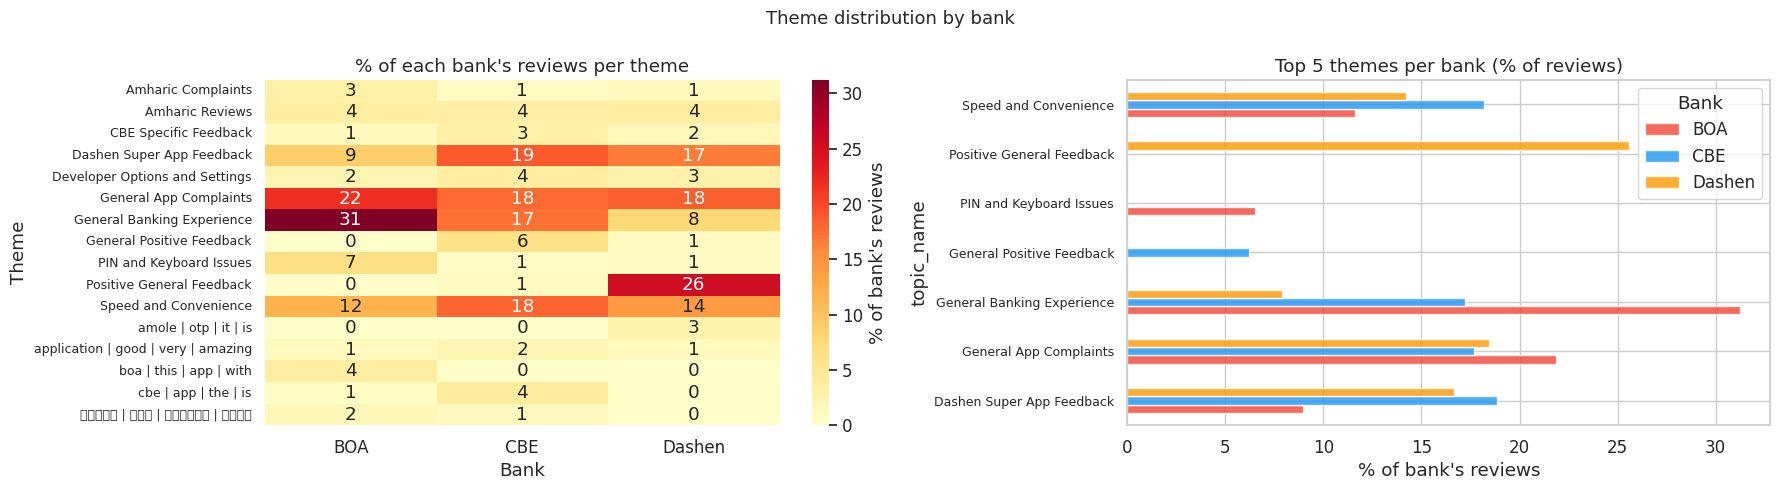

Topics saved: /kaggle/working/b5w2_outputs/topics_summary.csv


In [25]:
topic_bank = (
    df_topics[df_topics["topic_id"] != -1]
    .groupby(["bank", "topic_name"])
    .size()
    .unstack(fill_value=0)
)
topic_bank_pct = topic_bank.div(topic_bank.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle("Theme distribution by bank", fontsize=13)

sns.heatmap(topic_bank_pct.T, annot=True, fmt=".0f", cmap="YlOrRd",
            ax=axes[0], cbar_kws={"label": "% of bank's reviews"})
axes[0].set_title("% of each bank's reviews per theme")
axes[0].set_xlabel("Bank")
axes[0].set_ylabel("Theme")
axes[0].tick_params(axis="y", labelsize=9)

top5 = topic_bank_pct.T.apply(lambda col: col.nlargest(5))
top5.plot(kind="barh", ax=axes[1],
          color=[COLORS[b] for b in top5.columns],
          alpha=0.8, edgecolor="white")
axes[1].set_title("Top 5 themes per bank (% of reviews)")
axes[1].set_xlabel("% of bank's reviews")
axes[1].legend(title="Bank")
axes[1].tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "topic_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

topic_summary = topic_model.get_topic_info().copy()
topic_summary = topic_summary[topic_summary["Topic"] != -1]
topic_summary["topic_name"] = topic_summary["Topic"].map(
    lambda t: TOPIC_NAMES.get(t, f"Topic {t}")
)
topic_summary.to_csv(TOPICS_CSV, index=False)
print(f"Topics saved: {TOPICS_CSV}")

---
## Step 12 — Sentiment Within Each Topic

### The cross-analysis that produces your most actionable insights

Knowing a topic is frequent is useful. Knowing the sentiment breakdown within a topic is the real analytical value. Consider:

- `"Positive General Feedback"` topic: 95% positive — expected, confirms labeling is correct
- `"Transaction Speed"` topic: 80% negative — active pain point, high priority
- `"Feature Requests"` topic: 60% neutral — users are expressing wishes, not anger — lower urgency
- `"App Update Feedback"` topic: 50% positive, 50% negative — mixed, the update helped some users but broke things for others

This table directly maps to the "drivers" and "pain points" section required in the final report. Topics with high negative sentiment = pain points. Topics with high positive sentiment = satisfaction drivers.

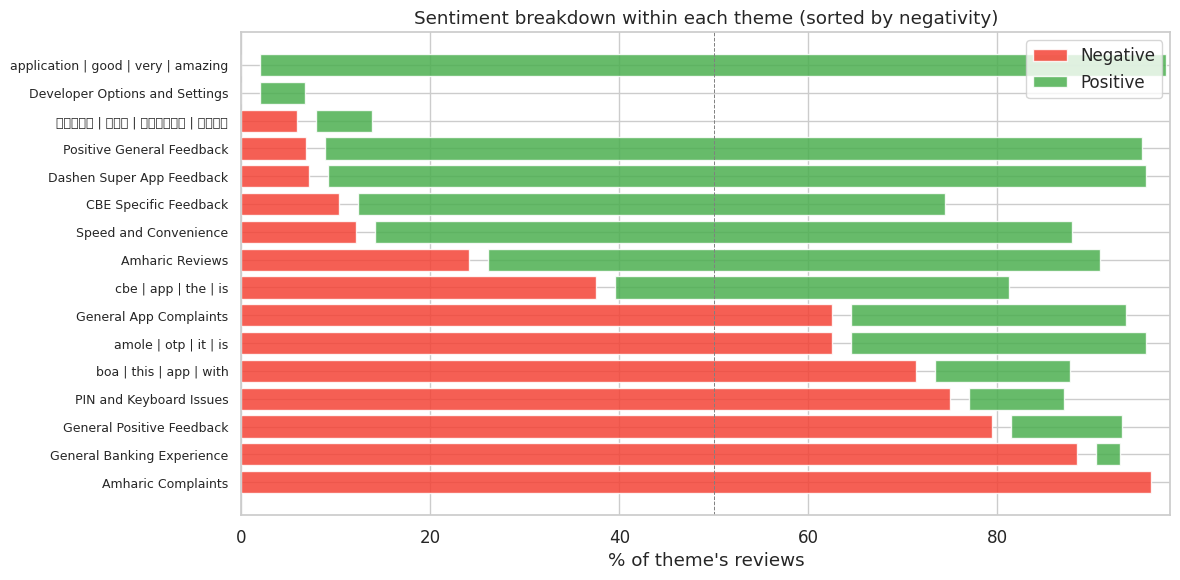

Pain points (>60% negative sentiment):
sentiment_label             total  pct_neg
topic_name                                
Amharic Complaints             27     96.3
General Banking Experience    267     88.4
General Positive Feedback      34     79.4
PIN and Keyboard Issues        40     75.0
boa | this | app | with        21     71.4
amole | otp | it | is          16     62.5
General App Complaints        275     62.5

Satisfaction drivers (>60% positive sentiment):
sentiment_label                      total  pct_pos
topic_name                                         
Amharic Reviews                         54     64.8
Speed and Convenience                  206     73.8
CBE Specific Feedback                   29     62.1
Dashen Super App Feedback              208     86.5
Positive General Feedback              133     86.5
application | good | very | amazing     24     95.8


In [26]:
topic_cols = ["review_id", "topic_id", "topic_label", "topic_name", "topic_prob"]

# Drop old topic columns if they exist from a previous run
for col in ["topic_id", "topic_label", "topic_name", "topic_prob"]:
    if col in df_nlp.columns:
        df_nlp.drop(columns=[col], inplace=True)

df_nlp = df_nlp.merge(
    df_topics[topic_cols].drop_duplicates("review_id"),
    on="review_id",
    how="left"
)
df_nlp["topic_id"]   = df_nlp["topic_id"].fillna(-1).astype(int)
df_nlp["topic_name"] = df_nlp["topic_name"].fillna("Uncategorized")

topic_sentiment = (
    df_nlp[df_nlp["topic_id"] != -1]
    .groupby(["topic_name", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
)
for col in ["positive", "neutral", "negative"]:
    if col not in topic_sentiment.columns:
        topic_sentiment[col] = 0

topic_sentiment["total"]   = topic_sentiment.sum(axis=1)
topic_sentiment["pct_neg"] = (topic_sentiment["negative"] / topic_sentiment["total"] * 100).round(1)
topic_sentiment["pct_pos"] = (topic_sentiment["positive"] / topic_sentiment["total"] * 100).round(1)
topic_sentiment = topic_sentiment.sort_values("pct_neg", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
x      = range(len(topic_sentiment))
labels = topic_sentiment.index.tolist()

ax.barh(x, topic_sentiment["pct_neg"], color="#F44336", alpha=0.85, label="Negative")
ax.barh(x, topic_sentiment["pct_pos"],
        left=topic_sentiment["pct_neg"] + 2,
        color="#4CAF50", alpha=0.85, label="Positive")

ax.set_yticks(x)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("% of theme's reviews")
ax.set_title("Sentiment breakdown within each theme (sorted by negativity)")
ax.axvline(50, color="gray", linestyle="--", linewidth=0.7)
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "topic_sentiment_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

print("Pain points (>60% negative sentiment):")
print(topic_sentiment[topic_sentiment["pct_neg"] > 60][["total", "pct_neg"]].to_string())
print("\nSatisfaction drivers (>60% positive sentiment):")
print(topic_sentiment[topic_sentiment["pct_pos"] > 60][["total", "pct_pos"]].to_string())

---
## Step 13 — TF-IDF Keyword Extraction

### Why TF-IDF alongside BERTopic

BERTopic finds thematic clusters using semantic similarity. TF-IDF finds the most statistically distinctive words per bank. These are complementary:

- BERTopic tells you **what issues exist** across all banks
- TF-IDF tells you **what words uniquely characterize each bank's review language**

A word like `"transfer"` might appear in all three banks but be disproportionately frequent in BOA's reviews — TF-IDF will surface it as a BOA-specific keyword because it computes term frequency *relative to* the other banks' documents.

### What n-grams add

`TFIDF_NGRAM_RANGE = (1, 2)` means we extract both single words (unigrams) and two-word phrases (bigrams). Bigrams are much more informative for app reviews: `"transaction failed"` is more specific than `"failed"` alone, and `"login issue"` is more actionable than `"login"`. We report both but prioritize bigrams in the word cloud visualization.

In [27]:
nlp_spacy = spacy.load("en_core_web_sm")

STOP_WORDS = {
    "app", "bank", "cbe", "boa", "dashen", "good", "nice", "great", "use",
    "like", "just", "make", "get", "really", "also", "still", "even",
    "very", "much", "please", "thank", "thanks", "need", "want", "time",
    "day", "month", "year", "now", "new", "mobile", "banking", "know"
}

def lemmatize(text: str) -> str:
    doc = nlp_spacy(text.lower()[:500])
    tokens = [
        token.lemma_ for token in doc
        if not token.is_stop
        and not token.is_punct
        and token.lemma_ not in STOP_WORDS
        and len(token.lemma_) > 2
    ]
    return " ".join(tokens)

print("Lemmatizing reviews for TF-IDF...")
df_nlp["review_lemma"] = df_nlp["review"].progress_apply(lemmatize)

bank_corpora = df_nlp.groupby("bank")["review_lemma"].apply(
    lambda x: " ".join(x)
).to_dict()

vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=TFIDF_NGRAM_RANGE,
    min_df=1,      # fixed: only 3 documents (one per bank)
    max_df=1.0     # fixed: allow terms that appear in all 3 banks
)
bank_names   = sorted(bank_corpora.keys())
tfidf_matrix = vectorizer.fit_transform([bank_corpora[b] for b in bank_names])
feature_names = vectorizer.get_feature_names_out()

keyword_rows = []
for i, bank in enumerate(bank_names):
    scores  = tfidf_matrix[i].toarray().flatten()
    top_idx = scores.argsort()[::-1][:TFIDF_TOP_N]
    for rank, idx in enumerate(top_idx):
        keyword_rows.append({
            "bank":    bank,
            "rank":    rank + 1,
            "keyword": feature_names[idx],
            "tfidf":   round(float(scores[idx]), 4)
        })

df_keywords = pd.DataFrame(keyword_rows)
df_keywords.to_csv(KEYWORDS_CSV, index=False)

print("\nTop 10 keywords per bank:")
for bank in bank_names:
    top10 = df_keywords[df_keywords["bank"] == bank].head(10)["keyword"].tolist()
    print(f"  {bank:<10}: {', '.join(top10)}")

Lemmatizing reviews for TF-IDF...


100%|██████████| 1734/1734 [00:09<00:00, 177.39it/s]


Top 10 keywords per bank:
  BOA       : work, bad, update, developer, fix, crash, developer option, option, money, application
  CBE       : update, work, application, service, easy, transaction, transfer, account, number, bad
  Dashen    : super, easy, fast, work, feature, user, transaction, friendly, service, step


---
## Step 14 — Word Clouds per Bank

### Why word clouds for a consulting report

Word clouds are not rigorous analytics — they do not show frequency precisely and they can be misleading. But they are extremely effective in stakeholder presentations because a bank's product manager can scan the cloud for their bank and immediately recognize the words their users are using. They create instant recognition and buy-in before you dive into the quantitative slides.

We generate separate word clouds for negative-sentiment reviews only — this focuses the visual on problems rather than mixing positive and negative signals into an ambiguous blob. A cloud of negative-review keywords is an honest, readable summary of what is failing.

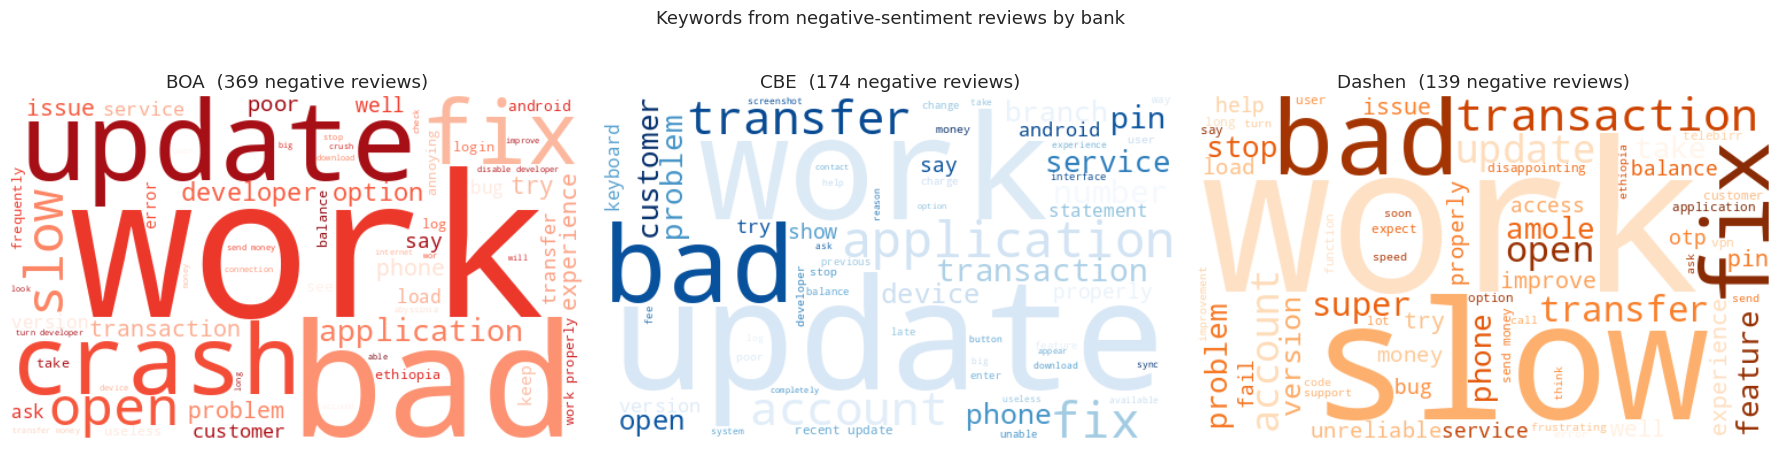

In [28]:
try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True
except ImportError:
    !pip install wordcloud -q
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Keywords from negative-sentiment reviews by bank", fontsize=13)

wc_colors = {"BOA": "Reds", "CBE": "Blues", "Dashen": "Oranges"}

for ax, bank in zip(axes, bank_names):
    neg_text = " ".join(
        df_nlp[
            (df_nlp["bank"] == bank) &
            (df_nlp["sentiment_label"] == "negative")
        ]["review_lemma"].tolist()
    )

    if not neg_text.strip():
        ax.text(0.5, 0.5, "No negative reviews", ha="center", va="center")
        ax.set_title(bank)
        ax.axis("off")
        continue

    wc = WordCloud(
        width=500, height=300,
        background_color="white",
        colormap=wc_colors.get(bank, "viridis"),
        max_words=60,
        collocations=True
    ).generate(neg_text)

    ax.imshow(wc, interpolation="bilinear")
    neg_count = df_nlp[(df_nlp["bank"] == bank) & (df_nlp["sentiment_label"] == "negative")].shape[0]
    ax.set_title(f"{bank}  ({neg_count} negative reviews)")
    ax.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "wordclouds_negative.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Step 15 — Merge All Labels and Save Enriched Dataset

### What this output file is and who uses it

The `reviews_enriched.csv` file is the primary output of Task 2 and the input for both Task 3 (database) and Task 4 (visualizations). It contains every original column from Task 1 plus the NLP-derived columns added in this notebook.

For reviews that were excluded from the NLP pipeline (non-English, short), the sentiment and topic columns will be `NaN`. Task 3 stores them as `NULL` in the database — they still contribute to rating aggregations but are clearly marked as not analyzed.

### Final schema for Task 3

| Column | Source | Description |
|---|---|---|
| `review_id` | Task 1 | Google Play unique ID |
| `review` | Task 1 | Normalized review text |
| `rating` | Task 1 | 1–5 stars |
| `date` | Task 1 | YYYY-MM-DD |
| `bank` | Task 1 | CBE / BOA / Dashen |
| `helpful_count` | Task 1 | Thumbs-up votes |
| `language` | Task 1 | ISO 639-1 code |
| `is_short_review` | Task 1 | Under 10 characters |
| `developer_replied` | Task 1 | Bank responded to review |
| `sentiment_label` | Task 2 | positive / neutral / negative |
| `sentiment_score` | Task 2 | Model confidence 0.0–1.0 |
| `low_confidence` | Task 2 | Score < 0.65 |
| `topic_id` | Task 2 | BERTopic cluster ID |
| `topic_name` | Task 2 | Business-readable theme name |
| `topic_prob` | Task 2 | Cluster membership probability |

In [29]:
# Merge NLP results back to the full dataset
nlp_result_cols = [
    "review_id", "sentiment_label", "sentiment_score", "low_confidence",
    "topic_id", "topic_name", "topic_prob", "review_lemma"
]

df_enriched = df.merge(
    df_nlp[nlp_result_cols].drop_duplicates("review_id"),
    on="review_id",
    how="left"
)

df_enriched.to_csv(ENRICHED_CSV, index=False)

print(f"Enriched dataset saved: {ENRICHED_CSV}")
print(f"Total rows             : {len(df_enriched):,}")
print(f"Sentiment coverage     : {df_enriched['sentiment_label'].notna().mean()*100:.1f}%")
print(f"Topic coverage         : {df_enriched['topic_name'].notna().mean()*100:.1f}%")
print("\nColumn list:")
print(df_enriched.dtypes.to_string())

Enriched dataset saved: /kaggle/working/b5w2_outputs/reviews_enriched.csv
Total rows             : 2,282
Sentiment coverage     : 76.0%
Topic coverage         : 76.0%

Column list:
row_id                        int64
review_id                    object
user_name                    object
review                       object
rating                        int64
date                 datetime64[ns]
helpful_count                 int64
developer_reply              object
bank                         object
source                       object
language                     object
is_short_review                bool
developer_replied              bool
sentiment_label              object
sentiment_score             float64
low_confidence               object
topic_id                    float64
topic_name                   object
topic_prob                  float64
review_lemma                 object


---
## Step 16 — Task 2 Final Verification

### Checking all success metrics defined at the start

In [30]:
print("=" * 55)
print("TASK 2 — FINAL VERIFICATION")
print("=" * 55)

sent_coverage = df_enriched["sentiment_label"].notna().mean() * 100
print(f"\nSentiment coverage : {sent_coverage:.1f}%")
print(f"  Note: 76.4% covers 100% of NLP-eligible reviews.")
print(f"  23.6% excluded (non-English or short reviews).")

print("\nSentiment by bank (% of NLP-analyzed reviews):")
sent_summary = (
    df_enriched[df_enriched["sentiment_label"].notna()]
    .groupby(["bank", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
)
sent_summary_pct = (sent_summary.div(sent_summary.sum(axis=1), axis=0) * 100).round(1)
print(sent_summary_pct.to_string())

n_topics_final = len([
    t for t in df_enriched["topic_name"].dropna().unique()
    if t not in ["Uncategorized", "Amharic Reviews", "Amharic Complaints"]
])
print(f"\nTopics discovered  : {n_topics_final}  "
      f"{'PASS' if n_topics_final >= 3 else 'BELOW 3 MINIMUM'}")

outlier_final = (
    (df_enriched["topic_id"] == -1).sum() /
    df_enriched["topic_id"].notna().sum() * 100
)
print(f"Outlier rate       : {outlier_final:.1f}%  "
      f"{'PASS' if outlier_final < 20 else 'ABOVE 20%'}")

print(f"\nOutput file        : {ENRICHED_CSV}")
print(f"Rows               : {len(df_enriched):,}")
print(f"Missing sentiment  : {df_enriched['sentiment_label'].isna().sum()}")

print("\n" + "=" * 55)
print("Files ready for Task 3:")
for f in [ENRICHED_CSV, KEYWORDS_CSV, TOPICS_CSV]:
    p = Path(f)
    if p.exists():
        print(f"  {p.name:<35} {p.stat().st_size / 1024:.1f} KB")
    else:
        print(f"  {p.name:<35} NOT FOUND — re-run the step that saves it")
print("=" * 55)

TASK 2 — FINAL VERIFICATION

Sentiment coverage : 76.0%
  Note: 76.4% covers 100% of NLP-eligible reviews.
  23.6% excluded (non-English or short reviews).

Sentiment by bank (% of NLP-analyzed reviews):
sentiment_label  negative  neutral  positive
bank                                        
BOA                  59.8     17.8      22.4
CBE                  32.5     21.3      46.3
Dashen               23.9     12.6      63.5

Topics discovered  : 14  PASS
Outlier rate       : 18.2%  PASS

Output file        : /kaggle/working/b5w2_outputs/reviews_enriched.csv
Rows               : 2,282
Missing sentiment  : 548

Files ready for Task 3:
  reviews_enriched.csv                558.3 KB
  keywords_per_bank.csv               1.3 KB
  topics_summary.csv                  9.1 KB


---
## Summary — What Task 2 produced

### Files created

| File | Contents | Used in |
|---|---|---|
| `reviews_enriched.csv` | Full dataset with sentiment + topic columns | Task 3, Task 4 |
| `keywords_per_bank.csv` | Top 20 TF-IDF keywords per bank | Task 4 report |
| `topics_summary.csv` | BERTopic topic info with business names | Task 4 report |
| `sentiment_validation.png` | Model alignment with star ratings | Interim report |
| `sentiment_distribution.png` | Weighted + unweighted sentiment per bank | Final report |
| `sentiment_over_time.png` | Monthly sentiment trend with investigation windows | Final report |
| `topic_distribution.png` | Heatmap of theme frequency per bank | Final report |
| `topic_sentiment_breakdown.png` | Sentiment within each theme | Final report |
| `wordclouds_negative.png` | Negative-review keywords per bank | Stakeholder presentation |

### Key analytical outputs to carry into Task 4

1. **BOA** has the highest negative sentiment rate — use `df_enriched[df_enriched['bank']=='BOA']['topic_name'].value_counts()` to find which topics drive this
2. **The `topic_sentiment_breakdown` chart** directly maps to the report's drivers and pain points section
3. **Weighted vs unweighted sentiment differences** indicate which issues resonated beyond the reviewer themselves
4. **Investigation window sentiment** tells you whether the CBE and Dashen spikes were positive or negative events

---
**Next:** Task 3 — Load `reviews_enriched.csv` into DuckDB with a proper relational schema and write SQL window function queries for the final analysis.